### 11 - Regressão SVM no California Housing

Exercício: treine e ajuste um regressor SVM no conjunto de dados California Housing. Você pode usar o conjunto original, obtido com `sklearn.datasets.fetch_california_housing()`. Os alvos representam centenas de milhares de dólares. Como há mais de 20.000 instâncias, SVMs podem ser lentas; portanto, para o ajuste de hiperparâmetros, use bem menos instâncias, por exemplo 2.000, para testar mais combinações. Qual é o RMSE do seu melhor modelo?


#### Imports


In [1]:
import sys
from packaging import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from scipy.stats import loguniform
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

assert sys.version_info >= (3, 7)
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

np.random.seed(42)


#### Carregamento dos dados


In [2]:
housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target


In [3]:
print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print(f"Atributos: {list(X.columns)}")

housing.frame.head()


Formato de X: (20640, 8)
Formato de y: (20640,)
Atributos: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### Separação treino/teste


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_train.shape, X_test.shape


((16512, 8), (4128, 8))

#### Subconjunto para busca de hiperparâmetros

O `SVR` com kernel RBF pode ser lento em conjuntos grandes. Por isso, a busca de hiperparâmetros será feita em apenas 2.000 instâncias do conjunto de treino.


In [5]:
rng = np.random.default_rng(42)
subset_indices = rng.choice(len(X_train), size=2_000, replace=False)

X_train_small = X_train.iloc[subset_indices]
y_train_small = y_train.iloc[subset_indices]

X_train_small.shape, y_train_small.shape


((2000, 8), (2000,))

#### Busca de hiperparâmetros

O pipeline escala os dados antes do `SVR`, pois SVMs são sensíveis à escala dos atributos. A busca testa combinações de `C`, `gamma` e `epsilon` em escala logarítmica.


In [6]:
svr_pipeline = make_pipeline(
    StandardScaler(),
    SVR(kernel="rbf"),
)

param_distributions = {
    "svr__C": loguniform(1, 1_000),
    "svr__gamma": loguniform(0.001, 1),
    "svr__epsilon": loguniform(0.01, 1),
}

rnd_search = RandomizedSearchCV(
    svr_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

_ = rnd_search.fit(X_train_small, y_train_small)


Fitting 3 folds for each of 15 candidates, totalling 45 fits


In [7]:
print(f"Melhor RMSE na validação cruzada: {-rnd_search.best_score_:.4f}")
rnd_search.best_params_


Melhor RMSE na validação cruzada: 0.5945


{'svr__C': np.float64(8.200518402245827),
 'svr__epsilon': np.float64(0.015679933916723017),
 'svr__gamma': np.float64(0.11290133559092672)}

#### Treinamento final

Depois de escolher os hiperparâmetros no subconjunto, treinamos o melhor modelo no conjunto de treino completo.


In [8]:
best_svr = rnd_search.best_estimator_
_ = best_svr.fit(X_train, y_train)


#### Avaliação no conjunto de teste


In [9]:
y_pred = best_svr.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RMSE no conjunto de teste: {test_rmse:.4f}")
print(f"Isso equivale a aproximadamente US$ {test_rmse * 100_000:,.0f}.")


RMSE no conjunto de teste: 0.5742
Isso equivale a aproximadamente US$ 57,423.


#### Gráfico de previsões


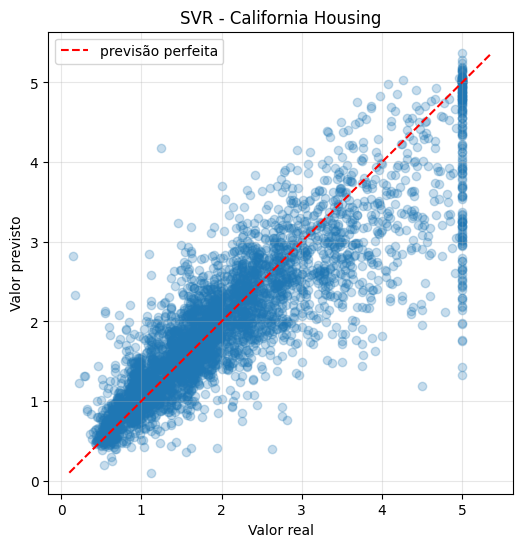

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.25)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], "r--", label="previsão perfeita")

plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("SVR - California Housing")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


O melhor modelo foi escolhido usando validação cruzada em 2.000 instâncias, e depois retreinado no conjunto de treino completo. O RMSE final deve ser interpretado em centenas de milhares de dólares, pois essa é a escala do alvo no California Housing.
